# 08 — Insights Summary

**Objective:** Consolidate the analysis from notebooks 03–06 into a concise, decision-oriented summary of Interfood's financial profile — the headline findings, the business dynamics behind them, and what they imply. This notebook is the project's "executive read" and doubles as a reference for the README.

**Inputs:**
- `../data/interfood.db` (to regenerate a couple of summary figures)

**Expected output:**
- A one-page written synthesis (6 key findings), a compact summary scorecard, and one consolidated chart pulling the story together.

**Audience framing:** written as a controller would summarise the business for management — what the numbers say, why, and what to watch.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

data_dir = Path("../data")
charts_dir = Path("../outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(data_dir / "interfood.db")
wide = (pd.read_sql_query("SELECT * FROM summary_series", conn)
        .pivot(index="year", columns="metric", values="value").sort_index())
conn.close()

# Regenerate the key derived series the summary references
gm = 100 * wide["gross_operating_income"] / wide["sales"]       # gross margin %
nm = 100 * wide["net_result"] / wide["sales"]                   # net margin %
rev_per_tonne = wide["sales"] / wide["volume_mt"]               # €/tonne
nwc_intensity = 100 * wide["net_working_capital"] / wide["sales"]

# Headline numbers for the narrative
print("Key figures for the summary:")
print(f"  Sales:        €{wide.loc[2017,'sales']/1000:,.0f}m (2017) -> €{wide.loc[2025,'sales']/1000:,.0f}m (2025)")
print(f"  Gross margin: {gm.min():.1f}% – {gm.max():.1f}% range")
print(f"  Net margin:   {nm.min():.2f}% – {nm.max():.2f}% range")
print(f"  Rev/tonne:    €{rev_per_tonne.min():,.0f} – €{rev_per_tonne.max():,.0f}")
print(f"  NWC:          €{wide.loc[2017,'net_working_capital']/1000:,.0f}m -> €{wide.loc[2025,'net_working_capital']/1000:,.0f}m")
print(f"  2025 net result: €{wide.loc[2025,'net_result']/1000:,.1f}m (lowest net margin in the series: {nm.loc[2025]:.2f}%)")
print(f"  2021 profit vs cash: €{wide.loc[2021,'net_result']/1000:,.1f}m profit / €{wide.loc[2021,'operating_cash_flow']/1000:,.1f}m op cash flow")

Key figures for the summary:
  Sales:        €1,767m (2017) -> €3,480m (2025)
  Gross margin: 2.4% – 5.9% range
  Net margin:   0.60% – 2.38% range
  Rev/tonne:    €1,820 – €3,080
  NWC:          €77m -> €213m
  2025 net result: €20.8m (lowest net margin in the series: 0.60%)
  2021 profit vs cash: €22.6m profit / €-90.4m op cash flow


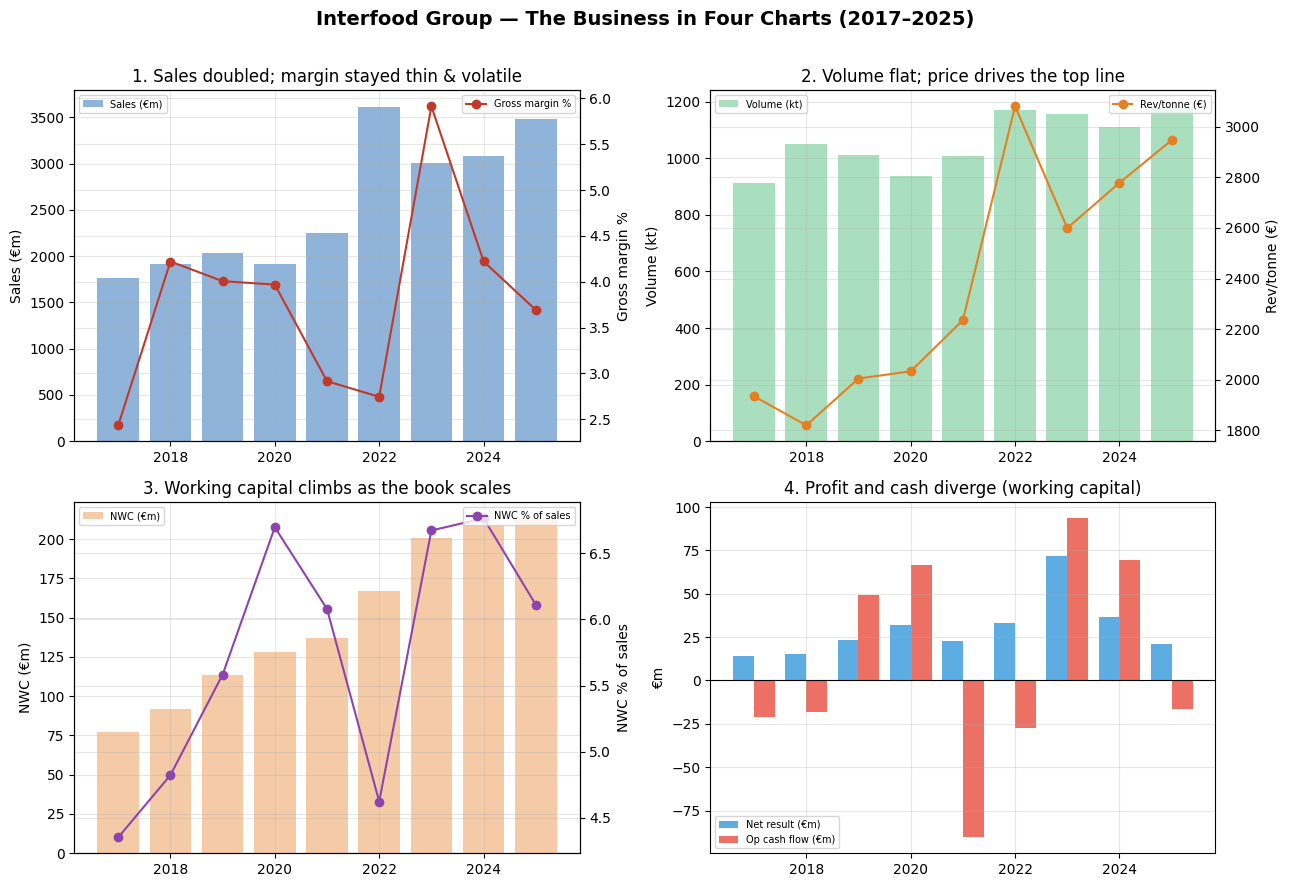

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Interfood Group — The Business in Four Charts (2017–2025)", fontsize=14, fontweight="bold")

# Panel 1: Sales doubling on thin, volatile margin
ax = axes[0, 0]
ax.bar(wide.index, wide["sales"]/1000, color="#8fb3d9", label="Sales (€m)")
ax2 = ax.twinx()
ax2.plot(wide.index, gm, color="#c0392b", marker="o", label="Gross margin %")
ax.set_title("1. Sales doubled; margin stayed thin & volatile")
ax.set_ylabel("Sales (€m)"); ax2.set_ylabel("Gross margin %")
ax.legend(loc="upper left", fontsize=7); ax2.legend(loc="upper right", fontsize=7)

# Panel 2: Revenue is price-driven, not volume-driven
ax = axes[0, 1]
ax.bar(wide.index, wide["volume_mt"], color="#a9dfbf", label="Volume (kt)")
ax2 = ax.twinx()
ax2.plot(wide.index, rev_per_tonne, color="#e67e22", marker="o", label="Rev/tonne (€)")
ax.set_title("2. Volume flat; price drives the top line")
ax.set_ylabel("Volume (kt)"); ax2.set_ylabel("Rev/tonne (€)")
ax.legend(loc="upper left", fontsize=7); ax2.legend(loc="upper right", fontsize=7)

# Panel 3: Working capital climbing
ax = axes[1, 0]
ax.bar(wide.index, wide["net_working_capital"]/1000, color="#f5cba7", label="NWC (€m)")
ax2 = ax.twinx()
ax2.plot(wide.index, nwc_intensity, color="#8e44ad", marker="o", label="NWC % of sales")
ax.set_title("3. Working capital climbs as the book scales")
ax.set_ylabel("NWC (€m)"); ax2.set_ylabel("NWC % of sales")
ax.legend(loc="upper left", fontsize=7); ax2.legend(loc="upper right", fontsize=7)

# Panel 4: Profit vs cash divergence
ax = axes[1, 1]
x = wide.index.astype(int); w = 0.4
ax.bar(x - w/2, wide["net_result"]/1000, width=w, color="#5dade2", label="Net result (€m)")
ax.bar(x + w/2, wide["operating_cash_flow"]/1000, width=w, color="#ec7063", label="Op cash flow (€m)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("4. Profit and cash diverge (working capital)")
ax.set_ylabel("€m")
ax.legend(loc="lower left", fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(charts_dir / "10_summary_panel.png", dpi=120, bbox_inches="tight")
plt.show()

## The business in six findings

**1. High volume, thin margin.**
Sales nearly doubled from €1.77bn (2017) to €3.48bn (2025), but gross operating margin stayed in a thin 2.4%–5.9% band and net margin between 0.6% and 2.4%. This is a high-turnover, low-margin trading model — protecting the spread is the whole game.

**2. Revenue is price-driven, not volume-driven.**
Volume is remarkably stable (~940–1,180 kt), while revenue per tonne swings hard (€1,820–€3,080). The €1.4bn sales jump in 2022 came almost entirely from dairy prices spiking, not from moving more product. A "record revenue year" often just means high prices — so revenue says little about how well the business actually traded.

**3. Margin is the real scoreboard, and it's volatile.**
2023's gross margin (5.9%) was more than double 2022's (2.75%) on *lower* sales — driven by how well the book was positioned against price, not by volume. This is precisely the volatility a Business Control function exists to manage.

**4. The business is capital-hungry and getting more so.**
Net working capital nearly tripled (€77m → €213m) as the book scaled. On a thin margin, every euro tied up in inventory and receivables has a real cost — which is why Interfood judges performance on economic profit (EPR), charging operating profit for the capital employed, rather than on accounting profit alone.

**5. Profit and cash can move in opposite directions.**
In 2021, Interfood earned €22.6m of profit but *consumed* €90.4m of operating cash — a record year that drained cash because working capital ballooned as prices rose. Working capital, not profit, drives cash for a trader — so a controller who watches only the P&L misses half the picture.

**6. 2025 was a genuinely hard year.**
Net result fell to €20.8m (the lowest net margin in the series, 0.6%), from €71.5m in 2023, with the €14.3m AS E-Piim supplier write-off a major drag, and solvency tightened to 24.5%. A single counterparty default consumed ~69% of the year's profit — a vivid illustration of why credit-risk discipline is central to the role.

## What it implies for a Business Controller

The through-line: **Interfood makes its money on a thin margin in a volatile market, while tying up growing amounts of capital.** That makes three things central to the control function — protecting margin, managing counterparty (credit) risk, and disciplining working capital — because on this financial profile, a small margin slip, a single default, or capital creep each destroys a disproportionate share of profit. The analysis in this project quantifies exactly why each of those matters.

## Conclusion

**What this project delivered:**
- A clean, provenance-tracked dataset of Interfood's 2017–2025 financials (notebooks 01–02).
- Controller-relevant analysis of margin, growth drivers, working capital, cash, and solvency (03).
- A counterparty credit-risk model anchored on the real E-Piim write-off (04).
- A driver-based projection (05) with scenario and goal-seek tooling (06).
- An interactive Excel model with live formulas and recalculating charts (07).
- This consolidated executive summary (08).

**The one-line read of the business:**
*Interfood is a high-volume, thin-margin, capital-intensive dairy trader whose performance turns on margin protection, credit discipline, and working-capital control — the three things a Business Controller is there to manage.*

**Possible extensions (post-project):**
- A fully articulated three-statement model with statement-level line items.
- A Streamlit dashboard for live interactive scenario/goal-seek analysis.
- Peer benchmarking against comparable dairy traders.